# ROSSMAN STORE SALES FORECASTING - APPENDIX

### THE DATA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

train = pd.read_csv("train.csv", sep = ',', parse_dates = ['Date'], dtype = {'StateHoliday': str}) #import dataset and parse dates
train['Year'] = pd.DatetimeIndex(train['Date']).year # add column for year
train['Month'] = pd.DatetimeIndex(train['Date']).month # add column for month
train['DayOfMonth'] = pd.DatetimeIndex(train['Date']).day # add column for month
train


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,DayOfMonth
0,1,5,2015-07-31,5263,555,1,1,0,1,2015,7,31
1,2,5,2015-07-31,6064,625,1,1,0,1,2015,7,31
2,3,5,2015-07-31,8314,821,1,1,0,1,2015,7,31
3,4,5,2015-07-31,13995,1498,1,1,0,1,2015,7,31
4,5,5,2015-07-31,4822,559,1,1,0,1,2015,7,31
...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,2013,1,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1,2013,1,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1,2013,1,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1,2013,1,1


In [2]:
train['Store'].nunique() # check number of stores

1115

In [3]:
train['DayOfWeek'].unique() #check values

array([5, 4, 3, 2, 1, 7, 6])

In [4]:
train['Date'].nunique() #check values

942

In [5]:
train['Open'].unique() #check values

array([1, 0])

In [6]:
train['Promo'].unique() #check values

array([1, 0])

In [7]:
train['StateHoliday'].unique()

array(['0', 'a', 'b', 'c'], dtype=object)

In [8]:
train['SchoolHoliday'].unique() #check values

array([1, 0])

***
### DATA CLEANING
##### Converting StateHoliday Values to Numeric Values

In [9]:
print(train.dtypes) #check data types of each column

Store                     int64
DayOfWeek                 int64
Date             datetime64[ns]
Sales                     int64
Customers                 int64
Open                      int64
Promo                     int64
StateHoliday             object
SchoolHoliday             int64
Year                      int64
Month                     int64
DayOfMonth                int64
dtype: object


In [10]:
train['StateHoliday'].unique() #identify values in column

array(['0', 'a', 'b', 'c'], dtype=object)

In [11]:
train['StateHoliday'].replace({'a': '1', 'b': '1', 'c': '1'}, inplace = True) # change values to 1 to indicate StateHoliday
train[['StateHoliday']] = train[['StateHoliday']].apply(pd.to_numeric) #convert column to numeric datatype
train['StateHoliday'].dtypes

dtype('int64')

##### Check for Missing or Incorrect Data

In [12]:
train.isnull().sum() # identify any missing data

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
Year             0
Month            0
DayOfMonth       0
dtype: int64

In [13]:
open_incorrect = train[(train['Sales'] == 0) & train['Open'] == 1].index # create index array for records were sales = 0 but store was open
train.loc[open_incorrect,'Open'] = 0 # update Open to closed

In [14]:
promo_incorrect = train[(train['Open'] == 0) & train['Promo'] == 1].index # create index array for records were sales = 0 but store was open
train.loc[promo_incorrect,'Promo'] = 0 # update Open to closed

##### Find & Remove Outliers 

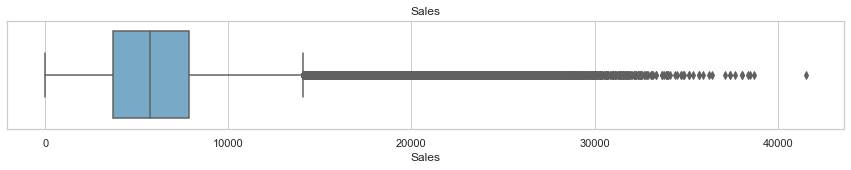

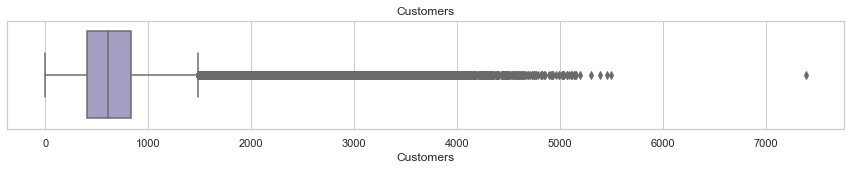

In [15]:
plt.figure(figsize = (15, 2))
sns.set(style = "whitegrid")
sns.boxplot(x = train['Sales'], palette = 'Blues') # create boxplot for continuous variable 'Sales'
plt.title('Sales');

plt.figure(figsize = (15, 2))
sns.set(style = "whitegrid")
sns.boxplot(x = train['Customers'], palette = 'Purples') # create boxplot for continuous variable 'Customers'
plt.title('Customers');

In [16]:
train = train.loc[(train['Sales'] < 40000) & (train['Customers'] < 7000)] # remove outliers for continuous outliers

##### Creating Data Subset for Top 200

In [17]:
summarybystore = train.groupby(['Store']).sum() # group by store
averagesales_open = pd.DataFrame({'Sales':summarybystore['Sales'], 'Open':summarybystore['Open'], 'Average Sales When Open':summarybystore['Sales']/summarybystore['Open']}) #calculate average sales per day when store open
averagesales_open.sort_values(by = ['Average Sales When Open'], inplace = True, ascending = False) # place in descending order by Sales
top200_averagesales_open = averagesales_open[0:200] # select top 200 rows
top200 = train[train.Store.isin(top200_averagesales_open.index.to_series())] # subset data using top 200 unique store ID numbers
top200_summary = top200.groupby('Store').sum()
top200_summary.sort_values(by = ['Sales'], inplace = True, ascending = False) # place in descending order by Sales
top200_summary

,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,DayOfMonth
Store,,,,,,,,,,
262,3766,19516842,3204694,942,360,24,169,1897035,5616,14796
817,3764,17030677,2446982,783,352,24,173,1895022,5615,14774
562,3766,16927322,2924960,942,360,24,209,1897035,5616,14796
1114,3766,16202585,2509542,784,353,24,169,1897035,5616,14796
251,3766,14896870,1908934,779,350,29,170,1897035,5616,14796
...,...,...,...,...,...,...,...,...,...,...
279,3033,5532919,415873,623,275,29,124,1526459,3869,11882
637,3033,5415918,431086,622,274,29,124,1526459,3869,11882
775,3033,5405733,386321,622,274,29,124,1526459,3869,11882


***

### EXPLORING THE DATA
##### Descriptive Statistics

In [18]:
train_closed = train[train['Open'] == 0].index # create array for row index where store closed
train_open = train.drop(train_closed) # drop rows where stores are closed
train_open1 = train_open.drop(['Date', 'Open', 'DayOfMonth'], axis = 1) # columns not needed
train_open1.loc[:, 'Av Customer Spend'] = train_open1['Sales']/train_open1['Customers'] # add column for average customer spend

cv1 = pd.Series(train_open1.std()/train_open1.mean(), name = 'cv') # create series for cv values
mode1 = pd.Series({'Store': np.nan, 'DayOfWeek':train_open1.DayOfWeek.mode()[0],
         'Sales': train_open1.Sales.mode()[0], 'Customers': train_open1.Customers.mode()[0],
         'Promo': train_open1.Promo.mode()[0], 'StateHoliday':train_open1.StateHoliday.mode()[0],
         'SchoolHoliday': train_open1.SchoolHoliday.mode()[0], 'Year': train_open1.Year.mode()[0],
         'Month': train_open1.Month.mode()[0], 'Av Customer Spend': round(train_open1['Av Customer Spend'],2).mode()[0]}, name = 'mode') # create series for mode values

descriptive_stats1 = train_open1.describe().apply(lambda s: s.apply('{0:.6f}'.format)) # get descriptive stats table
descriptive_stats1 = descriptive_stats1.append([cv1, mode1]).drop('count') # add cv & mode to table
descriptive_stats1 = descriptive_stats1.style.set_caption('All Stores - Descriptive Stats') # add title
descriptive_stats1

,Store,DayOfWeek,Sales,Customers,Promo,StateHoliday,SchoolHoliday,Year,Month,Av Customer Spend
mean,558.420652,3.520354,6955.894196,762.768185,0.446355,0.001078,0.193578,2013.831945,5.845779,9.493631
std,321.730893,1.723711,3103.512720,401.128478,0.497114,0.032812,0.395102,0.777271,3.323959,2.197384
min,1.000000,1.000000,46.000000,8.000000,0.000000,0.000000,0.000000,2013.000000,1.000000,2.749075
25%,280.000000,2.000000,4859.000000,519.000000,0.000000,0.000000,0.000000,2013.000000,3.000000,7.895574
50%,558.000000,3.000000,6369.000000,676.000000,0.000000,0.000000,0.000000,2014.000000,6.000000,9.250000
75%,837.000000,5.000000,8360.000000,893.000000,1.000000,0.000000,0.000000,2014.000000,8.000000,10.899729
max,1115.000000,7.000000,38722.000000,5494.000000,1.000000,1.000000,1.000000,2015.000000,12.000000,64.957854
cv,0.576144,0.489641,0.446170,0.525885,1.113718,30.444094,2.041048,0.000386,0.568608,0.231459
mode,nan,6.000000,5674.000000,560.000000,0.000000,0.000000,0.000000,2013.000000,1.000000,8.220000


In [19]:
top200_closed = top200[top200['Open'] == 0].index # create array for row index where store closed
top200_open = top200.drop(top200_closed) # drop rows where stores are closed
top200_open1 = top200_open.drop(['Date', 'Open'], axis = 1) # columns not needed
top200_open1.loc[:, 'Av Customer Spend'] = top200_open1['Sales']/top200_open1['Customers'] # add column for average customer spend

cv1 = pd.Series(top200_open1.std()/top200_open1.mean(), name = 'cv') # create series for cv values
mode1 = pd.Series({'Store': np.nan, 'DayOfWeek':top200_open1.DayOfWeek.mode()[0],
         'Sales': top200_open1.Sales.mode()[0], 'Customers': top200_open1.Customers.mode()[0],
         'Promo': top200_open1.Promo.mode()[0], 'StateHoliday':top200_open1.StateHoliday.mode()[0],
         'SchoolHoliday': top200_open1.SchoolHoliday.mode()[0], 'Year': top200_open1.Year.mode()[0],
         'Month': top200_open1.Month.mode()[0], 'Av Customer Spend': round(top200_open1['Av Customer Spend'],2).mode()[0]}, name = 'mode') # create series for mode values

descriptive_stats2 = top200_open1.describe().apply(lambda s: s.apply('{0:.6f}'.format)) # get descriptive stats table
descriptive_stats2 = descriptive_stats2.append([cv1, mode1]).drop('count') # add cv & mode to table
descriptive_stats2 = descriptive_stats2.style.set_caption('Top 200 Stores - Descriptive Stats') # add title
descriptive_stats2

,Store,DayOfWeek,Sales,Customers,Promo,StateHoliday,SchoolHoliday,Year,Month,DayOfMonth,Av Customer Spend
mean,569.035674,3.532950,10776.266119,1235.489791,0.445046,0.001866,0.195599,2013.832493,5.868643,15.829745,9.382270
std,311.007341,1.732852,3689.557845,595.087917,0.496973,0.043160,0.396663,0.774708,3.329892,8.688392,2.372685
min,4.000000,1.000000,520.000000,85.000000,0.000000,0.000000,0.000000,2013.000000,1.000000,1.000000,2.749075
25%,335.000000,2.000000,8226.500000,853.000000,0.000000,0.000000,0.000000,2013.000000,3.000000,8.000000,7.735190
50%,544.000000,4.000000,10024.000000,1085.000000,0.000000,0.000000,0.000000,2014.000000,6.000000,16.000000,9.108835
75%,826.000000,5.000000,12454.000000,1420.000000,1.000000,0.000000,0.000000,2014.000000,8.000000,23.000000,10.897665
max,1114.000000,7.000000,38722.000000,5494.000000,1.000000,1.000000,1.000000,2015.000000,12.000000,31.000000,24.595318
cv,0.546552,0.490483,0.342378,0.481662,1.116676,23.126439,2.027935,0.000385,0.567404,0.548865,0.252890
mode,nan,6.000000,8995.000000,962.000000,0.000000,0.000000,0.000000,2013.000000,1.000000,nan,7.940000


##### Distribution of the Continuous Variables

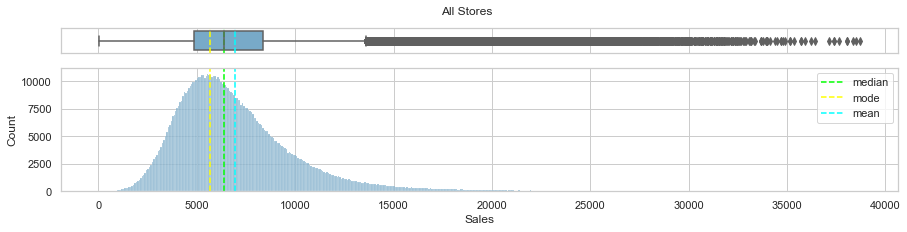

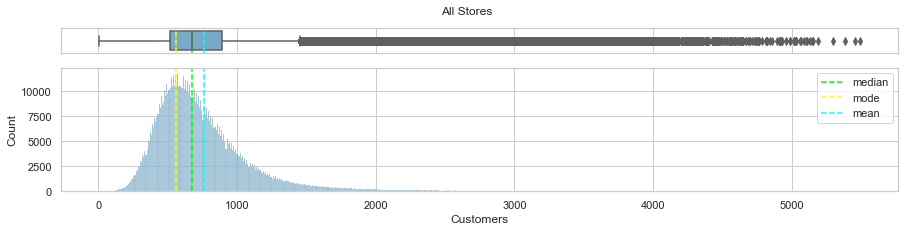

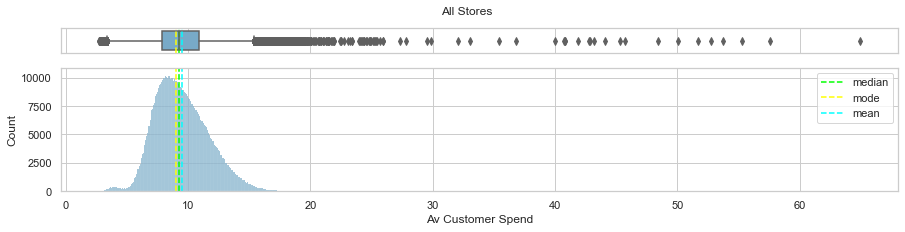

In [20]:
for var in ['Sales', 'Customers', 'Av Customer Spend']: # plot continuous variables
    f, (ax_box, ax_dist) = plt.subplots(2, figsize = (15, 3), sharex = True, gridspec_kw = {"height_ratios": (0.2, 1)})
    
    sns.boxplot(data = train_open1, x = var, ax = ax_box, palette = 'Blues')
    ax_box.axvline(train_open1[var].median(), color = 'lime', linestyle = '--', label = 'median') # plot median line
    ax_box.axvline(train_open1[var].mode()[0], color = 'yellow', linestyle = '--', label = 'mode') # plot mode line
    ax_box.axvline(train_open1[var].mean(), color = 'cyan', linestyle = '--', label = 'mean') # plot mean line

    sns.histplot(data = train_open1, x = var, ax = ax_dist, color = '#78AAC8')
    ax_dist.axvline(train_open1[var].median(), color = 'lime', linestyle = '--', label = 'median') # plot median line
    ax_dist.axvline(train_open1[var].mode()[0], color = 'yellow', linestyle = '--', label = 'mode') # plot mode line
    ax_dist.axvline(train_open1[var].mean(), color = 'cyan', linestyle = '--', label = 'mean') # plot mean line

    ax_dist.legend()
    ax_box.set(xlabel = '')
    plt.suptitle('All Stores', fontsize = 12)
    plt.show();


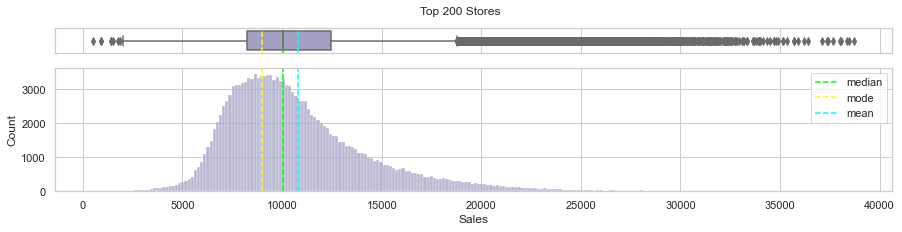

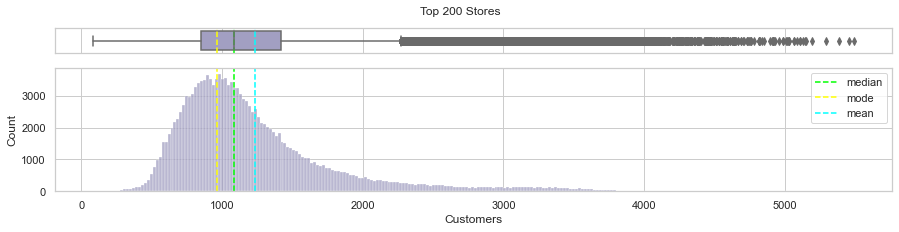

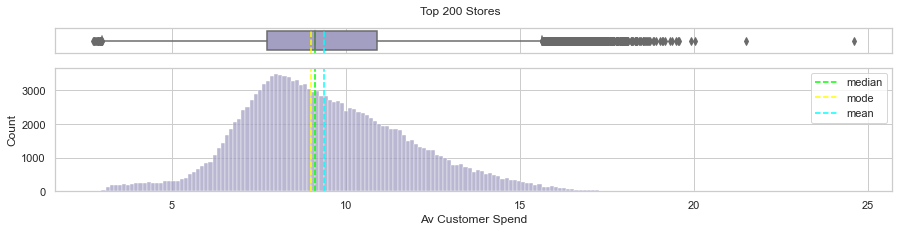

In [21]:
for var in ['Sales', 'Customers', 'Av Customer Spend']: # plot continuous variables
    f, (ax_box, ax_dist) = plt.subplots(2, figsize = (15, 3), sharex = True, gridspec_kw = {"height_ratios": (0.2, 1)})
    
    sns.boxplot(data = top200_open1, x = var, ax = ax_box, palette = 'Purples')
    ax_box.axvline(top200_open1[var].median(), color = 'lime', linestyle = '--', label = 'median') # plot median line
    ax_box.axvline(top200_open1[var].mode()[0], color = 'yellow', linestyle = '--', label = 'mode') # plot mode line
    ax_box.axvline(top200_open1[var].mean(), color = 'cyan', linestyle = '--', label = 'mean') # plot mean line

    sns.histplot(data = top200_open1, x = var, ax = ax_dist, color = '#A29FC2')
    ax_dist.axvline(top200_open1[var].median(), color = 'lime', linestyle = '--', label = 'median') # plot median line
    ax_dist.axvline(top200_open1[var].mode()[0], color = 'yellow', linestyle = '--', label = 'mode') # plot mode line
    ax_dist.axvline(top200_open1[var].mean(), color = 'cyan', linestyle = '--', label = 'mean') # plot mean line

    ax_dist.legend()
    ax_box.set(xlabel = '')
    plt.suptitle('Top 200 Stores', fontsize = 12)
    plt.show()

##### Distribution of the Categorical Variables

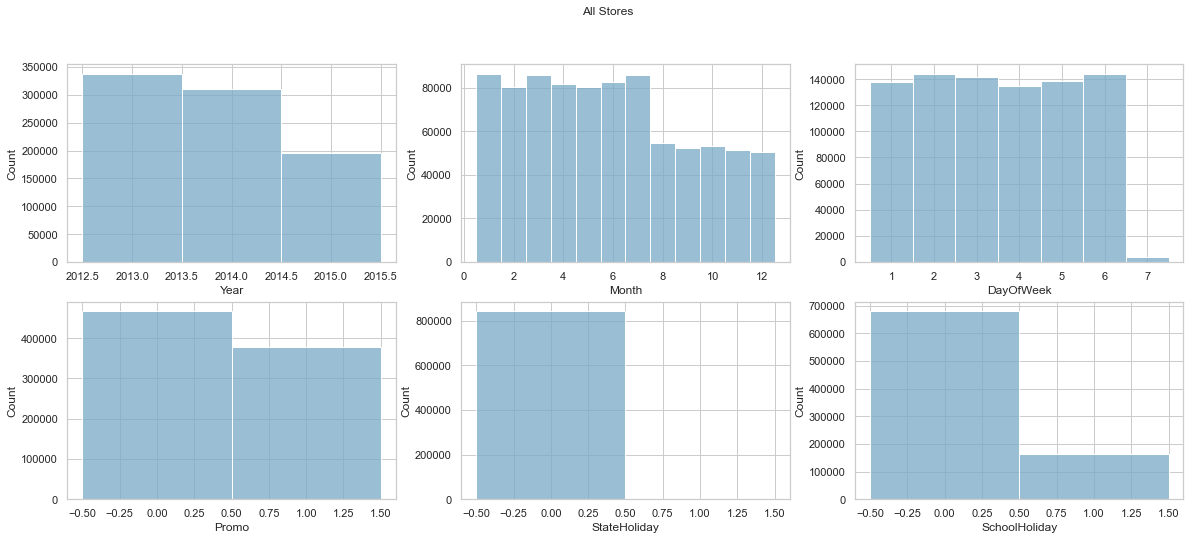

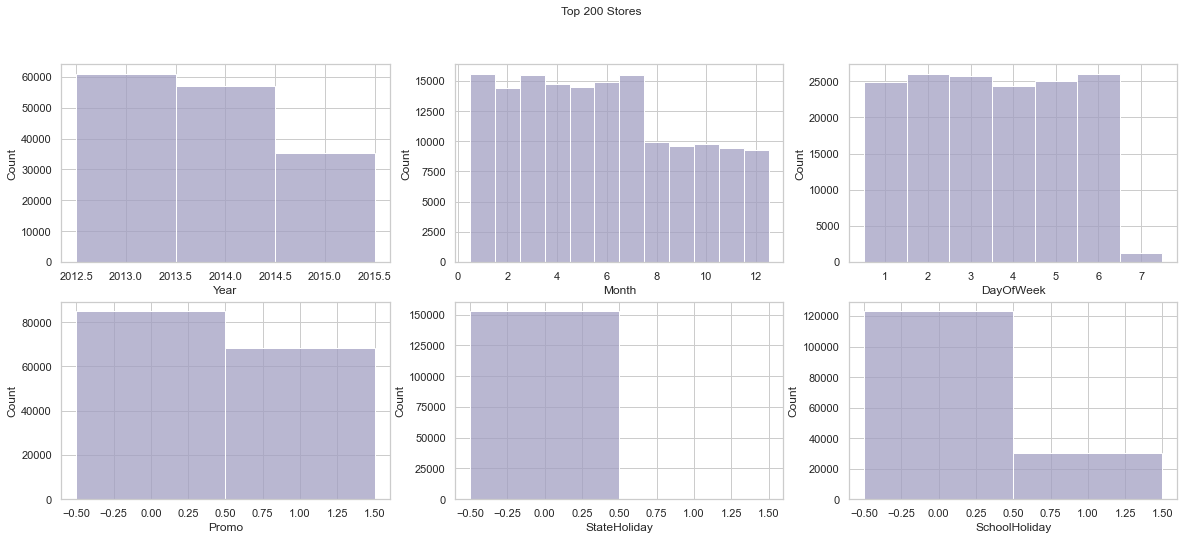

In [22]:
fig, ax = plt.subplots(2, 3, figsize = (20, 8)) # plot discrete variables for all stores
plt.suptitle('All Stores', fontsize = 12)
sns.histplot(train_open1, x = 'Year', color = '#78AAC8', discrete = True, ax = ax[0, 0])
sns.histplot(train_open1, x = 'Month', color = '#78AAC8', discrete = True, ax = ax[0, 1])
sns.histplot(train_open1, x = 'DayOfWeek', color = '#78AAC8', discrete = True, ax = ax[0, 2])
sns.histplot(train_open1, x = 'Promo', color = '#78AAC8', discrete = True, ax = ax[1, 0])
sns.histplot(train_open1, x = 'StateHoliday', color = '#78AAC8', discrete = True, ax = ax[1, 1])
sns.histplot(train_open1, x = 'SchoolHoliday', bins = 2, color = '#78AAC8', discrete = True, ax = ax[1, 2])

fig, ax = plt.subplots(2, 3, figsize = (20, 8)) # plot discrete variables for top 200
plt.suptitle('Top 200 Stores', fontsize = 12)
sns.histplot(top200_open1, x = 'Year', color = '#A29FC2', discrete = True, ax = ax[0, 0])
sns.histplot(top200_open1, x = 'Month', color = '#A29FC2', discrete = True, ax = ax[0, 1])
sns.histplot(top200_open1, x = 'DayOfWeek', color = '#A29FC2', discrete = True, ax = ax[0, 2])
sns.histplot(top200_open1, x = 'Promo', color = '#A29FC2', discrete = True, ax = ax[1, 0])
sns.histplot(top200_open1, x = 'StateHoliday', color = '#A29FC2', discrete = True, ax = ax[1, 1])
sns.histplot(top200_open1, x = 'SchoolHoliday', bins = 2, color = '#A29FC2', discrete = True, ax = ax[1, 2]);

##### Sales Performance by Year

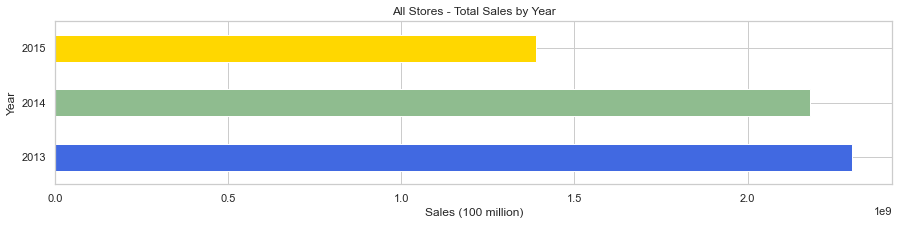

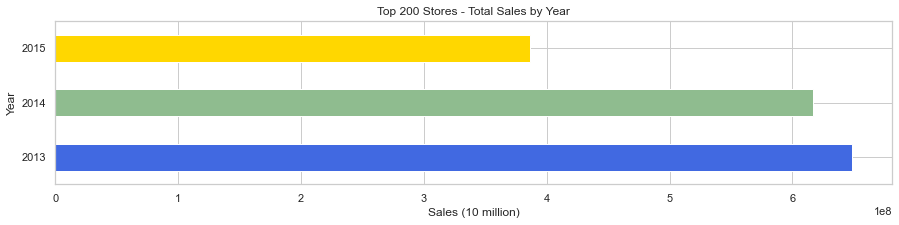

In [23]:
train_salesbyyear = train.groupby('Year').sum() # group by year
train_salesbyyear = train_salesbyyear.drop(['Store', 'DayOfWeek', 'Customers', 'Open', 'Promo', 'SchoolHoliday', 'StateHoliday', 'Month', 'DayOfMonth'], axis = 1) # remove all columns except for Sales
train_salesbyyear.plot.barh(figsize = (15, 3), color = ('royalblue', 'darkseagreen', 'gold'), legend = False) # plot bar graph
plt.xlabel('Sales (100 million)') # set label for x-axis
plt.title('All Stores - Total Sales by Year'); # set title of graph

top200_salesbyyear = top200.groupby('Year').sum() # group by year
top200_salesbyyear = top200_salesbyyear.drop(['Store', 'DayOfWeek', 'Customers', 'Open', 'Promo', 'SchoolHoliday', 'StateHoliday', 'Month', 'DayOfMonth'], axis = 1) # remove all columns except for Sales
top200_salesbyyear.plot.barh(figsize = (15, 3), color = ('royalblue', 'darkseagreen', 'gold'), legend = False) # plot bar graph
plt.xlabel('Sales (10 million)') # set label for x-axis
plt.title('Top 200 Stores - Total Sales by Year'); # set title of graph

##### Sales Performance by Month

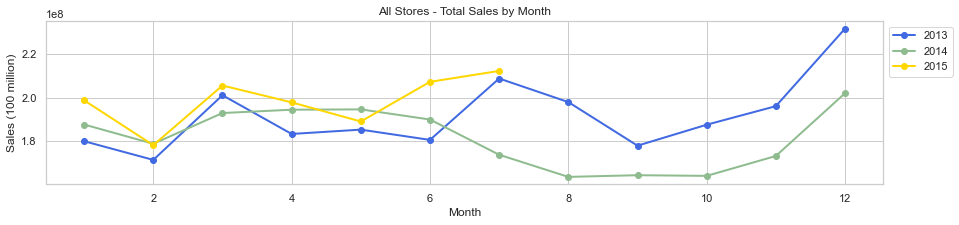

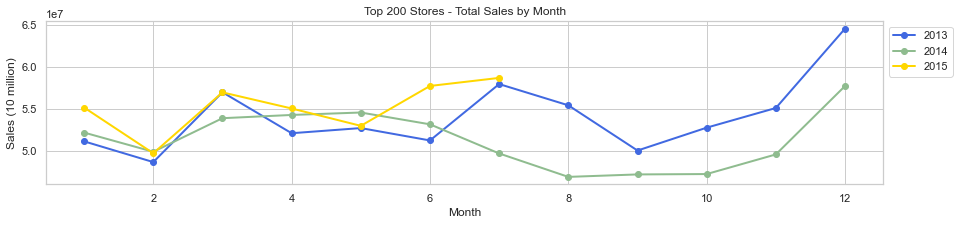

In [24]:
train_salesbymonth = train.groupby(['Month', 'Year']) # group by month by year
train_salesbymonth = train_salesbymonth['Sales'].sum().unstack() # sum totals

train_salesbymonth.plot(figsize = (15, 3), linewidth = 2, marker = 'o', color = ['royalblue', 'darkseagreen', 'gold']) # plot line graph, set markers for each month
plt.legend(bbox_to_anchor = (1, 1)) # set legend outside graph
plt.ylabel('Sales (100 million)') # set label for x-axis
plt.title('All Stores - Total Sales by Month') # set title of graph

top200_salesbymonth = top200.groupby(['Month', 'Year']) # group by month by year
top200_salesbymonth = top200_salesbymonth['Sales'].sum().unstack() # sum totals

top200_salesbymonth.plot(figsize = (15, 3), linewidth = 2, marker = 'o', color = ['royalblue', 'darkseagreen', 'gold']) # plot line graph, set markers for each month
plt.legend(bbox_to_anchor = (1, 1)) # set legend outside graph
plt.ylabel('Sales (10 million)') # set label for x-axis
plt.title('Top 200 Stores - Total Sales by Month'); # set title of graph

##### Trends by Month

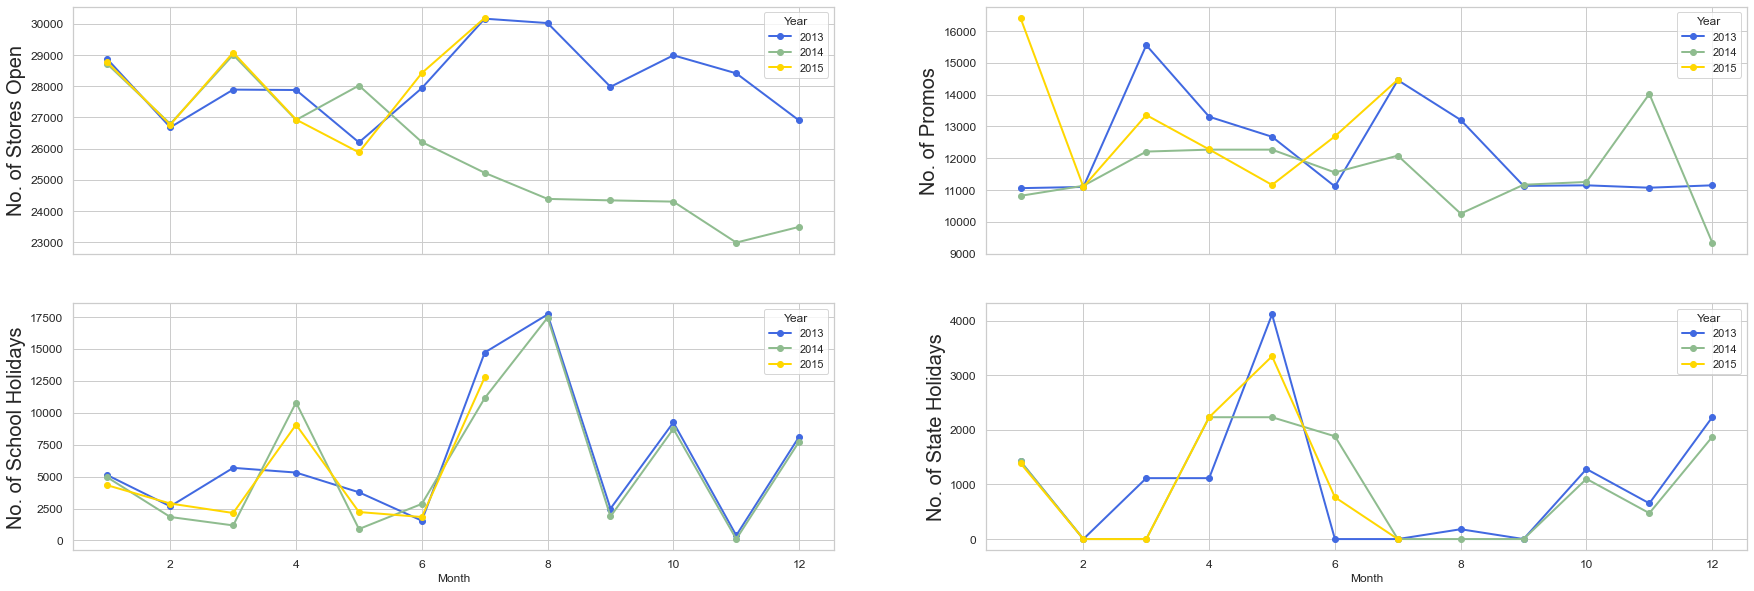

In [25]:
fig, ax = plt.subplots(2, 2, figsize = (30, 10), sharex = True) # set rows & columns for subplots, share x-axis labels

train_openbymonth = train.groupby(['Month', 'Year']) # group by month by year
train_openbymonth = train_openbymonth['Open'].sum().unstack() # sum by Open
train_openbymonth.plot(linewidth = 2, marker = 'o', color = ['royalblue', 'darkseagreen', 'gold'], ax = ax[0, 0], fontsize = 12) # plot line graph with marker for each month
ax[0, 0].set_ylabel('No. of Stores Open', fontsize = 20) # set label

train_promobymonth = train.groupby(['Month', 'Year']) # group by month by year
train_promobymonth = train_promobymonth['Promo'].sum().unstack() # sum by Promo
train_promobymonth.plot(linewidth = 2, marker = 'o', color = ['royalblue', 'darkseagreen', 'gold'], ax = ax[0, 1], fontsize = 12) # plot line graph with marker for each month
ax[0, 1].set_ylabel('No. of Promos', fontsize = 20) # set label

train_SCHbymonth = train.groupby(['Month', 'Year']) # group by month by year
train_SCHbymonth = train_SCHbymonth['SchoolHoliday'].sum().unstack() #sum by SchoolHoliday
train_SCHbymonth.plot(linewidth = 2, marker = 'o', color = ['royalblue', 'darkseagreen', 'gold'], ax = ax[1, 0], fontsize = 12) # plot line graph with marker for each month
ax[1, 0].set_ylabel('No. of School Holidays', fontsize = 20) # set label


train_STHbymonth = train.groupby(['Month', 'Year']) # group by month by year
train_STHbymonth = train_STHbymonth['StateHoliday'].sum().unstack() # sum by StateHoliday
train_STHbymonth.plot(linewidth = 2, marker = 'o', color = ['royalblue', 'darkseagreen', 'gold'], ax = ax[1, 1], fontsize = 12) # plot line graph with marker for each month
ax[1, 1].set_ylabel('No. of State Holidays', fontsize = 20); # set label

In [26]:
train_openbymonth['Days in Month'] = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31] # add column with no. of days in each month
train_openbymonth['If All Open'] = (train_openbymonth['Days in Month'] * 1115) # add column for value expected if all stores were open each day in month
train_openbymonth['% Stores Open 2013'] = (train_openbymonth.iloc[:, 0])/train_openbymonth['If All Open'] * 100 # get percentage of no. of stores open 
train_openbymonth['% Stores Open 2014'] = (train_openbymonth.iloc[:, 1])/train_openbymonth['If All Open'] * 100 # get percentage of no. of stores open
train_openbymonth['% Stores Open 2015'] = (train_openbymonth.iloc[:, 2])/train_openbymonth['If All Open'] * 100 # get percentage of no. of stores open
train_openbymonth = train_openbymonth.drop(['Days in Month', 'If All Open'], axis = 1) # columns not needed
train_openbymonth = train_openbymonth.round(decimals = 0) # rounding
train_openbymonth = train_openbymonth.fillna(0)
train_openbymonth[6:12] # view July - December

Year,2013,2014,2015,% Stores Open 2013,% Stores Open 2014,% Stores Open 2015
Month,,,,,,
7,30164.0,25224.0,30188.0,87.0,73.0,87.0
8,30023.0,24388.0,0.0,87.0,71.0,0.0
9,27980.0,24341.0,0.0,84.0,73.0,0.0
10,28990.0,24301.0,0.0,84.0,70.0,0.0
11,28412.0,22989.0,0.0,85.0,69.0,0.0
12,26901.0,23492.0,0.0,78.0,68.0,0.0


##### Sales Performance by Day of the Week

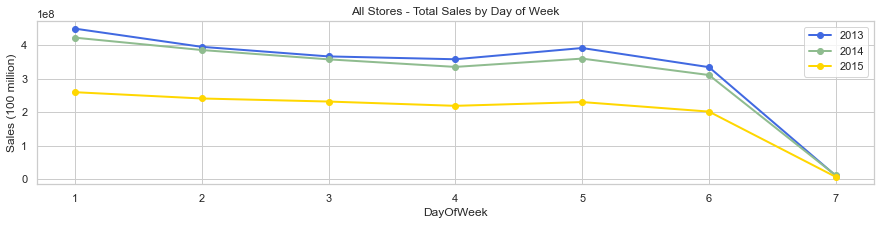

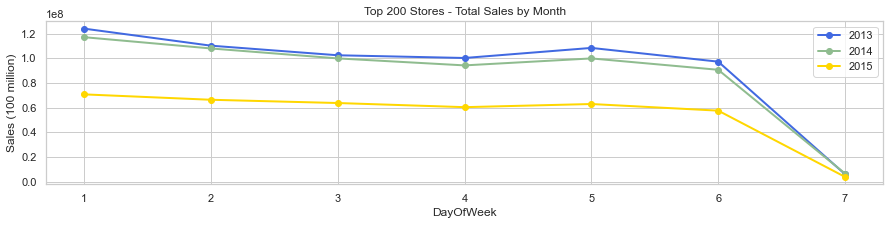

In [27]:
train_salesbydayofweek = train.groupby(['DayOfWeek', 'Year']) # group by day of week by year
train_salesbydayofweek = train_salesbydayofweek['Sales'].sum().unstack() # sum totals

train_salesbydayofweek.plot(figsize = (15, 3), linewidth = 2, marker = 'o', color = ['royalblue', 'darkseagreen', 'gold']) # plot line graph, set markers for each day
plt.legend(bbox_to_anchor = (1, 1)) # set legend outside graph
plt.ylabel('Sales (100 million)') # set label for x-axis
plt.title('All Stores - Total Sales by Day of Week') # set title of graph

top200_salesbydayofweek = top200.groupby(['DayOfWeek', 'Year']) # group by day of week by year
top200_salesbydayofweek = top200_salesbydayofweek['Sales'].sum().unstack() # sum totals

top200_salesbydayofweek.plot(figsize = (15, 3), linewidth = 2, marker = 'o', color = ['royalblue', 'darkseagreen', 'gold']) # plot line graph, set markers for each month
plt.legend(bbox_to_anchor = (1, 1)) # set legend outside graph
plt.ylabel('Sales (100 million)') # set label for x-axis
plt.title('Top 200 Stores - Total Sales by Month'); # set title of graph

In [28]:
train_openbydayofweek = train.groupby('DayOfWeek').sum() # get totals by day of week
train_openbydayofweek = train_openbydayofweek.drop(['Store', 'Customers', 'Promo', 'StateHoliday', 'SchoolHoliday', 'Year', 'Month', 'DayOfMonth'], axis = 1) #columns not needed
train_openbydayofweek

,Sales,Open
DayOfWeek,,
1,1130161461,137556
2,1020384740,143954
3,954962863,141922
4,911177709,134626
5,980555941,138633
6,846317735,144052
7,29551433,3593


##### Correlations Between All Variables

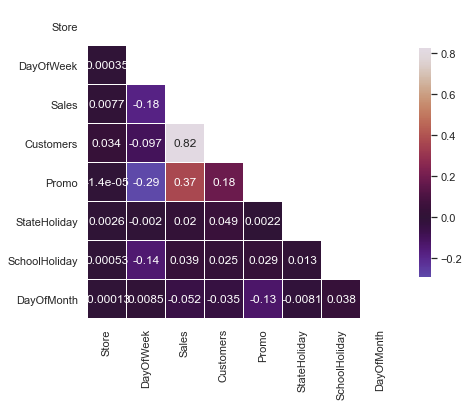

In [29]:
train_open2 = train_open.drop(['Open', 'Year', 'Month'], axis = 1) # columns not needed
train_open_corr = train_open2.corr() # correlations between variables
mask = np.triu(np.ones_like(train_open_corr, dtype = np.bool)) # hide repeated correlations
f, ax = plt.subplots(figsize = (7, 7)) # set size for plot
sns.heatmap(train_open_corr, mask = mask, center = 0, annot = True, square = True, linewidths = 0.5, cmap = 'twilight', cbar_kws={'shrink': 0.6}); # create heatmap, reducing cmap legend

##### Customers

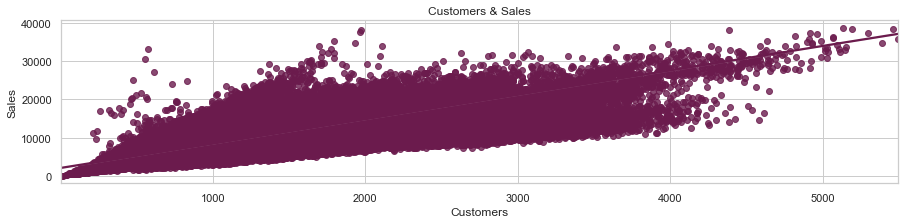

In [30]:
plt.figure(figsize = (15,3))
sns.regplot(data = train_open2, x = 'Customers', y = 'Sales', color = '#6B1B4D')
plt.title('Customers & Sales');

##### Promotions

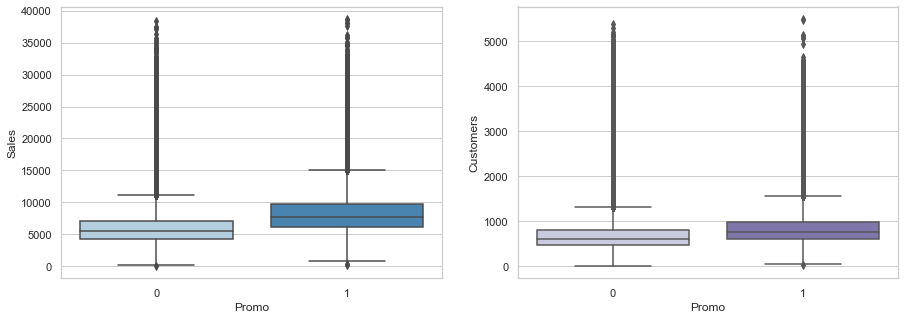

In [31]:
fig, ax = plt.subplots(1, 2, figsize = (15, 5)) # set rows & columns for subplots
sns.boxplot(data = train_open2, x = 'Promo', y = 'Sales', palette = 'Blues', ax = ax[0]) # plot comparison to sales
sns.boxplot(data = train_open2, x = 'Promo', y = 'Customers', palette = 'Purples', ax = ax[1]); # plot comparison to customers

In [32]:
opentrain_promo = train_open.groupby('Promo').sum() # get totals by promo value
opentrain_promo['Average Sales/Day Open'] = opentrain_promo['Sales'] / opentrain_promo['Open'] # calculate average sales per day
opentrain_promo['Average Customers/Day Open'] = opentrain_promo['Customers'] / opentrain_promo['Open']  # calculate average customers per day
opentrain_promo = opentrain_promo.drop(['Store', 'DayOfWeek', 'Sales', 'Customers', 'Open', 'StateHoliday', 'SchoolHoliday', 'Year', 'Month'], axis = 1) # columns not needed 
opentrain_promo = opentrain_promo.round(decimals = 2) # rounding
opentrain_promo

,DayOfMonth,Average Sales/Day Open,Average Customers/Day Open
Promo,,,
0,7863429,5929.75,696.90
1,5507215,8228.69,844.46


In [33]:
diff_avsales = ((opentrain_promo.at[1, 'Average Sales/Day Open']/opentrain_promo.at[0, 'Average Sales/Day Open']) - 1) * 100 # calculate difference (as percentage) based on promo value 
diff_avcustomers = ((opentrain_promo.at[1, 'Average Customers/Day Open']/opentrain_promo.at[0, 'Average Customers/Day Open']) - 1) * 100 # calculate difference (as percentage) based on promo value 

print('Difference in Average Sales/Day Open:', round(diff_avsales, 2), '%')
print('Difference in Average Customers/Day Open:', round(diff_avcustomers, 2), '%')

Difference in Average Sales/Day Open: 38.77 %
Difference in Average Customers/Day Open: 21.17 %


##### Day of the Week

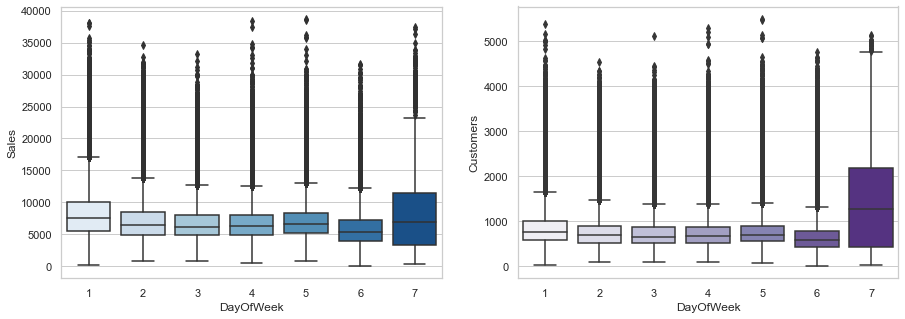

In [34]:
fig, ax = plt.subplots(1, 2, figsize = (15, 5)) # set rows & columns for subplots
sns.boxplot(data = train_open, x = 'DayOfWeek', y = 'Sales', palette = 'Blues', ax = ax[0]) # plot comparison to sales
sns.boxplot(data = train_open, x = 'DayOfWeek', y = 'Customers', palette = 'Purples', ax = ax[1]); # plot comparison to customers

##### School & State Holidays

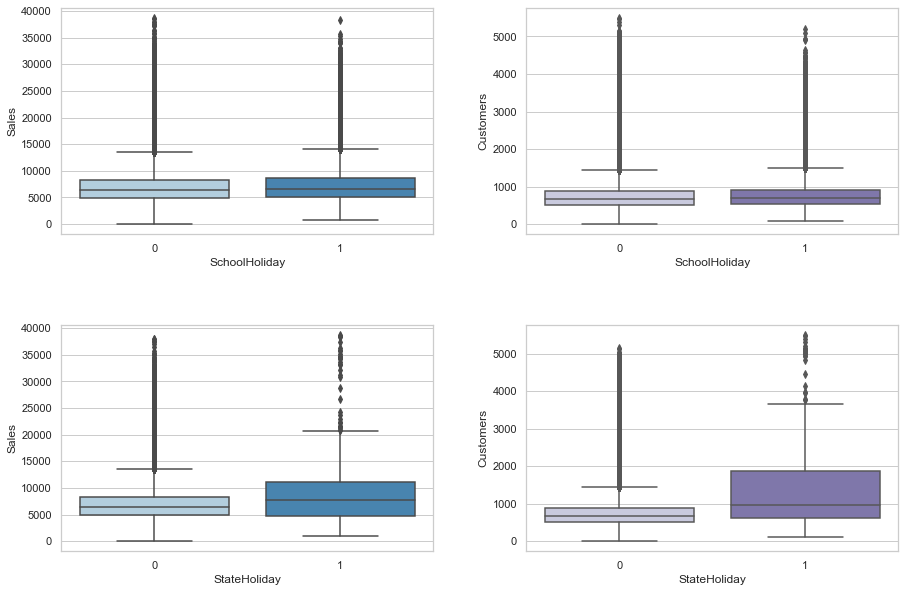

In [35]:
fig = plt.figure(figsize = (15, 10)) # set figure size
fig.subplots_adjust(hspace = 0.4, wspace = 0.25) # set parameters for subplots

ax = fig.add_subplot(2, 2, 1)
sns.boxplot(data = train_open, x = 'SchoolHoliday', y = 'Sales', palette = 'Blues', ax = ax) # plot SCH comparison to sales 

ax = fig.add_subplot(2, 2, 2)
sns.boxplot(data = train_open, x = 'SchoolHoliday', y = 'Customers', palette = 'Purples', ax = ax) # plot SCH comparison to customers

ax = fig.add_subplot(2, 2, 3)
sns.boxplot(data = train_open, x = 'StateHoliday', y = 'Sales', palette = 'Blues', ax = ax) # plot STH comparison to sales 

ax = fig.add_subplot(2, 2, 4)
sns.boxplot(data = train_open, x = 'StateHoliday', y = 'Customers', palette = 'Purples', ax = ax); # plot STH comparison to customers

In [36]:
opentrain_STH = train_open.groupby('StateHoliday').sum() # get totals by STH value
opentrain_STH['Average Sales'] = opentrain_STH['Sales'] / opentrain_STH['Open'] # calculate average sales per day based on StateHoliday value
opentrain_STH['Average Customers'] = opentrain_STH['Customers'] / opentrain_STH['Open'] # calculate average sales per day based on StateHoliday value
opentrain_STH['% Promo'] = (opentrain_STH['Promo'] / opentrain_STH['Open']) * 100 # calculate average sales per day based on StateHoliday value
opentrain_STH = opentrain_STH.drop(['Store', 'DayOfWeek', 'Sales', 'Customers', 'Open', 'Promo', 'SchoolHoliday', 'Year', 'Month'], axis = 1)
opentrain_STH = opentrain_STH.round(decimals = 0) # rounding
opentrain_STH

,DayOfMonth,Average Sales,Average Customers,% Promo
StateHoliday,,,,
0,13358178,6954.0,762.0,45.0
1,12466,8809.0,1367.0,48.0


In [37]:
diff_avsales1 = ((opentrain_STH.at[1, 'Average Sales']/opentrain_STH.at[0, 'Average Sales']) - 1) * 100 # calculate difference (as percentage) based on promo value 
diff_avcustomers1 = ((opentrain_STH.at[1, 'Average Customers']/opentrain_STH.at[0, 'Average Customers']) - 1) * 100 # calculate difference (as percentage) based on promo value 

print('Difference in Average Sales on State Holidays:', round(diff_avsales1, 2), '%')
print('Difference in Average Customers on State Holidays:', round(diff_avcustomers1, 2), '%')

Difference in Average Sales on State Holidays: 26.68 %
Difference in Average Customers on State Holidays: 79.4 %


***

### CREATING THE MODEL

#### One-Dimensional Regression Modelling

In [38]:
top200_july2015 = top200[(top200['Year'] == 2015) & (top200['Month'] == 7)].index
top200_training = top200.drop(top200_july2015)
top200_training

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,DayOfMonth
34568,4,2,2015-06-30,13106,1488,1,1,0,0,2015,6,30
34571,7,2,2015-06-30,14838,1325,1,1,0,0,2015,6,30
34588,24,2,2015-06-30,18220,1236,1,1,0,1,2015,6,30
34589,25,2,2015-06-30,16572,1880,1,1,0,1,2015,6,30
34591,27,2,2015-06-30,19780,1617,1,1,0,1,2015,6,30
...,...,...,...,...,...,...,...,...,...,...,...,...
1017185,1092,2,2013-01-01,0,0,0,0,1,1,2013,1,1
1017190,1097,2,2013-01-01,5961,1405,1,0,1,1,2013,1,1
1017194,1101,2,2013-01-01,0,0,0,0,1,1,2013,1,1
1017205,1112,2,2013-01-01,0,0,0,0,1,1,2013,1,1


##### Sales Prediction using Customers

In [39]:
X1 = top200_training[['Customers']] # create df for input values
Y1 = top200_training['Sales'] # create df for output values

X1_train, X1_test, Y1_train, Y1_test = train_test_split(X1, Y1, test_size = 0.8, random_state = 42) #split data into training & testing sets 
linear1 = LinearRegression(fit_intercept = True) # instantatiate model
linear1.fit(X1_train, Y1_train) # fit data to model

training_score1 = linear1.score(X1_train, Y1_train) # calculate rsq for training set
preds_1 = linear1.predict(X1_test) # use testing set to predict target variables
testing_score1 = r2_score(Y1_test, preds_1) # calculate correlation of predicted & actual target variables

print("Training score is", np.round(training_score1, 3))
print("Testing score is", np.round(testing_score1, 3))
print("Coefficients are", np.round(linear1.coef_, 2))

Training score is 0.745
Testing score is 0.747
Coefficients are [6.31]


##### Sales Prediction using Promo

In [40]:
X2 = top200_training[['Promo']] # create df for input values
X2 = pd.get_dummies(data = X2, drop_first = True) # convert categorical variable into dummy variables
Y2 = top200_training['Sales'] # create df for output values

X2_train, X2_test, Y2_train, Y2_test = train_test_split(X2, Y2, test_size = 0.8, random_state = 42) #split data into training & testing sets 
linear2 = LinearRegression(fit_intercept = True) # instantatiate model
linear2.fit(X2_train, Y2_train) # fit data to model

training_score2 = linear2.score(X2_train, Y2_train) # calculate rsq for training set
preds_2 = linear2.predict(X2_test) # use testing set to predict target variables
testing_score2 = r2_score(Y2_test, preds_2) # calculate correlation of predicted & actual target variables

print("Training score is", np.round(training_score2, 3))
print("Testing score is", np.round(testing_score2, 3))
print("Coefficients are", np.round(linear2.coef_, 3))

Training score is 0.274
Testing score is 0.269
Coefficients are [5663.725]


##### Sales Prediction using SchoolHoliday

In [41]:
X3 = top200_training[['SchoolHoliday']] # create df for input values
X3 = pd.get_dummies(data = X3, drop_first = True) # convert categorical variable into dummy variables
Y3 = top200_training['Sales'] # create df for output values

X3_train, X3_test, Y3_train, Y3_test = train_test_split(X3, Y3, test_size = 0.8, random_state = 42) #split data into training & testing sets 
linear3 = LinearRegression(fit_intercept = True) # instantatiate model
linear3.fit(X3_train, Y3_train) # fit data to model

training_score3 = linear3.score(X3_train, Y3_train) # calculate rsq for training set
preds_3 = linear3.predict(X3_test) # use testing set to predict target variables
testing_score3 = r2_score(Y3_test, preds_3) # calculate correlation of predicted & actual target variables

print("Training score is", np.round(training_score3, 3))
print("Testing score is", np.round(testing_score3, 3))
print("Coefficients are", np.round(linear3.coef_, 3))

Training score is 0.006
Testing score is 0.007
Coefficients are [1107.704]


##### Sales Prediction using StateHoliday

In [42]:
X4 = top200_training[['StateHoliday']] # create df for input values
X4 = pd.get_dummies(data = X4, drop_first = True) # convert categorical variable into dummy variables
Y4 = top200_training['Sales'] # create df for output values

X4_train, X4_test, Y4_train, Y4_test = train_test_split(X4, Y4, test_size = 0.8, random_state = 42) #split data into training & testing sets 
linear4 = LinearRegression(fit_intercept = True) # instantatiate model
linear4.fit(X4_train, Y4_train) # fit data to model

training_score4 = linear4.score(X4_train, Y4_train) # calculate rsq for training set
preds_4 = linear4.predict(X4_test) # use testing set to predict target variables
testing_score4 = r2_score(Y4_test, preds_4) # calculate correlation of predicted & actual target variables

print("Training score is", np.round(training_score4, 3))
print("Testing score is", np.round(testing_score4, 3))
print("Coefficients are", np.round(linear4.coef_, 3))

Training score is 0.082
Testing score is 0.078
Coefficients are [-8621.524]


#### Two-Dimensional Regression Modelling
##### Sales Prediction using Customers & Promo

In [43]:
X5 = top200_training[['Customers', 'Promo']] # create df for input values
X5 = pd.get_dummies(data = X5, drop_first = True) # convert categorical variable into dummy variables
Y5 = top200_training['Sales'] # create df for output values

X5_train, X5_test, Y5_train, Y5_test = train_test_split(X5, Y5, test_size = 0.8, random_state = 42) #split data into training & testing sets
linear5 = LinearRegression(fit_intercept = True) # instantatiate model
linear5.fit(X5_train, Y5_train) # fit data to model

training_score5 = linear5.score(X5_train, Y5_train) # calculate rsq for training set
preds_5 = linear5.predict(X5_test) # use testing set to predict target variables
testing_score5 = r2_score(Y5_test, preds_5) # calculate correlation of predicted & actual target variables

print("Training score is", np.round(training_score5, 3))
print("Testing score is", np.round(testing_score5, 3))
print("Coefficients are", np.round(linear5.coef_, 3))

Training score is 0.804
Testing score is 0.806
Coefficients are [   5.663 2801.465]


##### Sales Prediction using Customers & SchoolHoliday

In [44]:
X6 = top200_training[['Customers', 'SchoolHoliday']] # create df for input values
X6 = pd.get_dummies(data = X6, drop_first = True) # convert categorical variable into dummy variables
Y6 = top200_training['Sales'] # create df for output values

X6_train, X6_test, Y6_train, Y6_test = train_test_split(X6, Y6, test_size = 0.8, random_state = 42) #split data into training & testing sets 
linear6 = LinearRegression(fit_intercept = True) # instantatiate model
linear6.fit(X6_train, Y6_train) # fit data to model

training_score6 = linear6.score(X6_train, Y6_train) # calculate rsq for training set
preds_6 = linear6.predict(X6_test) # use testing set to predict target variables
testing_score6 = r2_score(Y6_test, preds_6) # calculate correlation of predicted & actual target variables

print("Training score is", np.round(training_score6, 3))
print("Testing score is", np.round(testing_score6, 3))
print("Coefficients are", np.round(linear6.coef_, 3))

Training score is 0.745
Testing score is 0.748
Coefficients are [  6.296 375.984]


##### Sales Prediction using Customers & StateHoliday

In [45]:
X7 = top200_training[['Customers', 'StateHoliday']] # create df for input values
X7 = pd.get_dummies(data = X7, drop_first = True) # convert categorical variable into dummy variables
Y7 = top200_training['Sales'] # create df for output values

X7_train, X7_test, Y7_train, Y7_test = train_test_split(X7, Y7, test_size = 0.8, random_state = 42) #split data into training & testing sets 
linear7 = LinearRegression(fit_intercept = True) # instantatiate model
linear7.fit(X7_train, Y7_train) # fit data to model

training_score7 = linear7.score(X7_train, Y7_train) # calculate rsq for training set
preds_7 = linear7.predict(X7_test) # use testing set to predict target variables
testing_score7 = r2_score(Y7_test, preds_7) # calculate correlation of predicted & actual target variables

print("Training score is", np.round(training_score7, 3))
print("Testing score is", np.round(testing_score7, 3))
print("Coefficients are", np.round(linear7.coef_, 3))

Training score is 0.752
Testing score is 0.755
Coefficients are [    6.156 -2663.268]


##### Sales Prediction using Promo & SchoolHoliday

In [46]:
X8 = top200_training[['Promo', 'SchoolHoliday']] # create df for input values
X8 = pd.get_dummies(data = X8, drop_first = True) # convert categorical variable into dummy variables
Y8 = top200_training['Sales'] # create df for output values

X8_train, X8_test, Y8_train, Y8_test = train_test_split(X8, Y8, test_size = 0.8, random_state = 42) #split data into training & testing sets 
linear8 = LinearRegression(fit_intercept = True) # instantatiate model
linear8.fit(X8_train, Y8_train) # fit data to model

training_score8 = linear8.score(X8_train, Y8_train) # calculate rsq for training set
preds_8 = linear8.predict(X8_test) # use testing set to predict target variables
testing_score8 = r2_score(Y8_test, preds_8) # calculate correlation of predicted & actual target variables

print("Training score is", np.round(training_score8, 3))
print("Testing score is", np.round(testing_score8, 3))
print("Coefficients are", np.round(linear8.coef_, 3))

Training score is 0.277
Testing score is 0.272
Coefficients are [5635.869  772.486]


##### Sales Prediction using Promo & StateHoliday

In [47]:
X9 = top200_training[['Promo', 'StateHoliday']] # create df for input values
X9 = pd.get_dummies(data = X9, drop_first = True) # convert categorical variable into dummy variables
Y9 = top200_training['Sales'] # create df for output values

X9_train, X9_test, Y9_train, Y9_test = train_test_split(X9, Y9, test_size = 0.8, random_state = 42) #split data into training & testing sets 
linear9 = LinearRegression(fit_intercept = True) # instantatiate model
linear9.fit(X9_train, Y9_train) # fit data to model

training_score9 = linear9.score(X9_train, Y9_train) # calculate rsq for training set
preds_9 = linear9.predict(X9_test) # use testing set to predict target variables
testing_score9 = r2_score(Y9_test, preds_9) # calculate correlation of predicted & actual target variables

print("Training score is", np.round(training_score9, 3))
print("Testing score is", np.round(testing_score9, 3))
print("Coefficients are", np.round(linear9.coef_, 3))

Training score is 0.322
Testing score is 0.315
Coefficients are [ 5349.103 -6671.432]


##### Sales Prediction using SchoolHoliday & StateHoliday

In [48]:
X10 = top200_training[['Promo', 'SchoolHoliday']] # create df for input values
X10 = pd.get_dummies(data = X10, drop_first = True) # convert categorical variable into dummy variables
Y10 = top200_training['Sales'] # create df for output values

X10_train, X10_test, Y10_train, Y10_test = train_test_split(X10, Y10, test_size = 0.8, random_state = 42) #split data into training & testing sets 
linear10 = LinearRegression(fit_intercept = True) # instantatiate model
linear10.fit(X10_train, Y10_train) # fit data to model

training_score10 = linear10.score(X10_train, Y10_train) # calculate rsq for training set
preds_10 = linear10.predict(X10_test) # use testing set to predict target variables
testing_score10 = r2_score(Y10_test, preds_10) # calculate correlation of predicted & actual target variables

print("Training score is", np.round(training_score10, 3))
print("Testing score is", np.round(testing_score10, 3))
print("Coefficients are", np.round(linear10.coef_, 3))

Training score is 0.277
Testing score is 0.272
Coefficients are [5635.869  772.486]


##### Compare Models

In [49]:
model_scores = {'Features':['Customers', 'Promo', 'SchoolHoliday', 'StateHoliday', 'Customers & Promo', 'Customers & SchoolHoliday', 'Customers & StateHoliday', 'Promo & SchoolHoliday', 'Promo & StateHoliday', 'SchoolHoliday & StateHoliday'], 
                'Target':['Sales', 'Sales', 'Sales', 'Sales', 'Sales', 'Sales', 'Sales', 'Sales', 'Sales', 'Sales'],
                'Training Score': [training_score1, training_score2, training_score3, training_score4, training_score5, training_score6, training_score7, training_score8, training_score9, training_score10],
                'Testing Score':[testing_score1, testing_score2, testing_score3, testing_score4, testing_score5, testing_score6, testing_score7, testing_score8, testing_score9, testing_score10],
                'Coefficients': [np.round(linear1.coef_, 2), np.round(linear2.coef_, 2), np.round(linear3.coef_, 2), np.round(linear4.coef_, 2), np.round(linear5.coef_, 2), np.round(linear6.coef_, 2), np.round(linear7.coef_, 2), np.round(linear8.coef_, 2), np.round(linear9.coef_, 2), np.round(linear10.coef_, 2)]} #create dictionary

model_compare = pd.DataFrame(model_scores) # create table for results
model_compare.sort_values(by = ['Testing Score'], inplace = True, ascending = False) # place in descending order by testing score
model_compare = model_compare.set_index('Features') # set index as input values for model
model_compare

,Target,Training Score,Testing Score,Coefficients
Features,,,,
Customers & Promo,Sales,0.803861,0.806195,"[5.66, 2801.47]"
Customers & StateHoliday,Sales,0.752087,0.754588,"[6.16, -2663.27]"
Customers & SchoolHoliday,Sales,0.745418,0.747893,"[6.3, 375.98]"
Customers,Sales,0.744689,0.747163,[6.31]
Promo & StateHoliday,Sales,0.322038,0.314702,"[5349.1, -6671.43]"
Promo & SchoolHoliday,Sales,0.276830,0.272019,"[5635.87, 772.49]"
SchoolHoliday & StateHoliday,Sales,0.276830,0.272019,"[5635.87, 772.49]"
Promo,Sales,0.273749,0.268713,[5663.72]
StateHoliday,Sales,0.082056,0.077938,[-8621.52]


### PREDICTING THE FUTURE
#### ATTEMPT 1
##### Create Dataset to Feed Model

In [50]:
pastjuly = top200_training[(top200_training['Month'] == 7)] # create data subset for july 2013 & 2014
average_pastjuly = pastjuly.groupby(['Store', 'DayOfMonth']).mean() # calculate average for each day by store

july2015 = top200[(top200['Year'] == 2015) & (top200['Month'] == 7)] # create data subset for july 2015
july2015_actualsales1 = july2015['Sales'] # create df for actual target variables

sales_fc_model = linear5 # rename selected model

##### Predict July 2015

In [51]:
input1 = average_pastjuly[['Customers', 'Promo']] # create df for input values
pred_july1 = sales_fc_model.predict(input1) # use model to predict output values

july2015_prediction1 = round(pred_july1.sum(), 2) # calculate total predicted sales for july 2015
july2015_actual1 = july2015[['Sales']].sum() # calculate actual total sales for july 2015

accuracy = round(r2_score(july2015_actualsales1, pred_july1), 3) # calculate correlation of predicted & actual target variables

results1 = {'Attempt': ['1'], 'Actual Sales': [int(july2015_actual1)], 
            'Predicted Sales': [int(july2015_prediction1)],
            '% Difference': [round((int(july2015_prediction1) - int(july2015_actual1))/int(july2015_actual1) * 100, 3)],
            'Accuracy Score': [accuracy]}

attempt1_results = pd.DataFrame(results1) # create table for results
attempt1_results.set_index('Attempt')

,Actual Sales,Predicted Sales,% Difference,Accuracy Score
Attempt,,,,
1,58674070,57133376,-2.626,-0.787


##### Compare Predicted Sales & Actual Sales

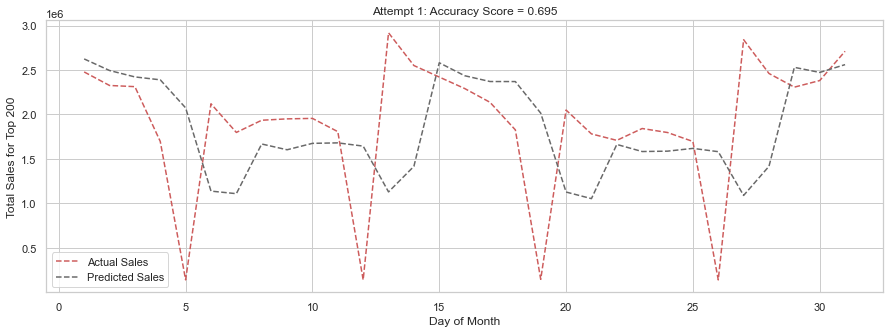

In [56]:
july2015_withpreds1 = july2015.groupby(['Store', 'DayOfMonth']).sum() # create df for july by totals
july2015_withpreds1['Predicted Sales'] = pred_july1.round(decimals = 0) # add column with predicted values
july2015_withpreds1 = july2015_withpreds1.groupby(['DayOfMonth']).sum() # calculate totals by day

plt.figure(figsize = (15,5))
plt.plot(list(range(1, 32)), july2015_withpreds1[['Sales']], label = 'Actual Sales', color = 'indianred', linestyle = 'dashed') # plot actual sales 
plt.plot(list(range(1, 32)), july2015_withpreds1[['Predicted Sales']], label = 'Predicted Sales', color = 'dimgray', linestyle = 'dashed') # plot predicted sales 
plt.legend()
plt.xlabel('Day of Month')
plt.ylabel('Total Sales for Top 200')
plt.title('Attempt 1: Accuracy Score = %s' % accuracy);

#### ATTEMPT 2
##### Create Dataset to Feed Model

In [53]:
remove1 = pastjuly[(pastjuly['Year'] == 2013) & (pastjuly['DayOfMonth'] < 3) | 
                   (pastjuly['Year'] == 2013) & (pastjuly['DayOfMonth'] > 30) |
                 (pastjuly['Year'] == 2014)].index # create array for indices of days to be excluded
july2013 = pastjuly.drop(remove1) # create new df with excluded dates for july 2013

remove2 = july2015[(july2015['Year'] == 2015) & (july2015['DayOfMonth'] > 28)].index # create array for indices of days to be excluded
july2015_2 = july2015.drop(remove2) # create new df with dates for july 2015

##### Predict July 2015

In [54]:
X = july2013[['Customers', 'Promo']] # create df for input values
pred_july2 = sales_fc_model.predict(X) # use model to predict output values

july2015_prediction2 = round(pred_july2.sum(), 2) # calculate total predicted sales for july 2015
july2015_actual2 = july2015_2[['Sales']].sum() # calculate actual total sales for july 2015

accuracy = round((r2_score(july2015_2['Sales'], pred_july2)), 3) # calculate correlation of predicted & actual target variables

results2 = {'Attempt': ['2'], 'Actual Sales': [int(july2015_actual2)], 
            'Predicted Sales': [int(july2015_prediction2)],
            '% Difference': [round((int(july2015_prediction2) - int(july2015_actual2))/int(july2015_actual2) * 100, 3)],
            'Accuracy Score': [accuracy]}

attempt2_results = pd.DataFrame(results2) # create table for results
attempt2_results.set_index('Attempt')

,Actual Sales,Predicted Sales,% Difference,Accuracy Score
Attempt,,,,
2,51274647,49802828,-2.87,0.695


##### Compare Predicted Sales & Actual Sales

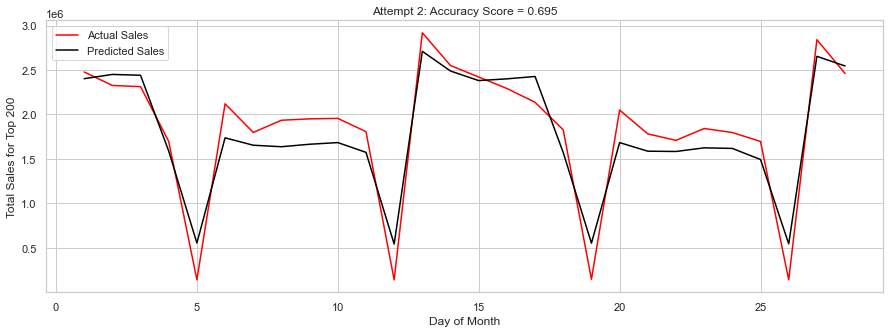

In [57]:
july2015_2['Predicted Sales'] = pred_july2.round(decimals = 0) # add column with predicted values
july2015_withpreds2 = july2015_2.groupby(['DayOfMonth']).sum() # calculate totals by day

plt.figure(figsize = (15,5))
plt.plot(list(range(1, 29)), july2015_withpreds2[['Sales']], label = 'Actual Sales', color = 'red') # plot actual sales 
plt.plot(list(range(1, 29)), july2015_withpreds2[['Predicted Sales']], label = 'Predicted Sales', color = 'black') # plot predicted sales 
plt.legend()
plt.xlabel('Day of Month')
plt.ylabel('Total Sales for Top 200')
plt.title('Attempt 2: Accuracy Score = %s' % accuracy);